In [5]:
import pandas as pd
df = pd.read_csv(r"F:\zizo\RTKCorrection\src\research\data\data_after_outlier_detection1.csv")
df.head()

,Unnamed: 0,GPST,avg_snr,min_snr,max_residual,x_x,y_x,z_x,ns,sdx(m),...,sdxy(m),sdyz(m),sdzx(m),x_y,y_y,z_y,diff_x,diff_y,diff_z,anomaly
0,0,2023-12-06 01:59:08,31.750000,26.0,1.6368,459252.2586,5.634018e+06,2.947007e+06,8.0,52.2081,...,40.7052,-37.1917,-50.0592,459291.9968,5.634082e+06,2.946966e+06,39.7382,64.6765,-40.9517,-1
1,1,2023-12-06 01:59:09,31.625000,25.0,1.7018,459252.7407,5.634016e+06,2.947006e+06,8.0,52.2223,...,40.7137,-37.1948,-50.0660,459289.5836,5.634087e+06,2.946966e+06,36.8429,71.1549,-39.4826,-1
2,2,2023-12-06 01:59:49,29.000000,23.0,5.5528,459308.8238,5.634051e+06,2.946946e+06,11.0,10.2943,...,3.2766,10.4717,-11.0646,459295.8737,5.634077e+06,2.946962e+06,-12.9501,26.0052,16.4584,-1
3,3,2023-12-06 02:06:09,27.500000,19.0,11.0868,459293.8285,5.634046e+06,2.946964e+06,16.0,4.6884,...,-2.4012,11.4236,-3.5037,459293.3256,5.634080e+06,2.946963e+06,-0.5029,34.6117,-0.4802,-1
4,4,2023-12-06 02:06:25,27.666667,16.0,11.5613,459294.7681,5.634057e+06,2.946969e+06,15.0,4.6947,...,-2.3391,12.0011,-3.4614,459285.2562,5.634097e+06,2.946964e+06,-9.5119,39.3426,-5.2728,-1


In [6]:
df.columns

Index(['Unnamed: 0', 'GPST', 'avg_snr', 'min_snr', 'max_residual', 'x_x',
       'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)', 'sdxy(m)', 'sdyz(m)',
       'sdzx(m)', 'x_y', 'y_y', 'z_y', 'diff_x', 'diff_y', 'diff_z',
       'anomaly'],
      dtype='object')

In [7]:
x = df[['avg_snr','min_snr','max_residual','x_x','y_x','z_x','ns','sdx(m)','sdy(m)','sdz(m)']]
y = df['anomaly']

In [8]:
y.value_counts()

anomaly
 1    107648
-1     18443
Name: count, dtype: int64

<BarContainer object of 2 artists>

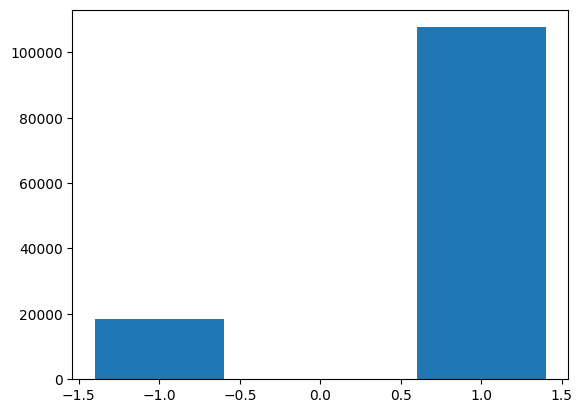

In [9]:
import matplotlib.pyplot as plt

plt.bar(y.value_counts().index, y.value_counts().values)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import numpy as np

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (100872, 10)
Testing set size: (25219, 10)


In [11]:
# Create and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,           # Maximum depth of trees
    min_samples_split=5,    # Minimum samples to split a node
    min_samples_leaf=2,     # Minimum samples in leaf nodes
    random_state=42,
    n_jobs=-1               # Use all processors
)

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

# Enhanced Evaluation Metrics for Imbalanced Classification
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import numpy as np

# Calculate comprehensive metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=-1)  # -1 is anomaly class
recall = recall_score(y_test, y_pred, pos_label=-1)
f1 = f1_score(y_test, y_pred, pos_label=-1)

# ROC-AUC Score (using probability predictions)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 0])  # probabilities for class -1

# Average Precision Score (better for imbalanced data than ROC-AUC)
avg_precision = average_precision_score(y_test == -1, y_pred_proba[:, 0])

print("="*60)
print("COMPREHENSIVE EVALUATION METRICS")
print("="*60)
print(f"\nOverall Metrics:")
print(f"  Accuracy:           {accuracy:.4f}")
print(f"\nAnomaly Detection Metrics (Class -1):")
print(f"  Precision:          {precision:.4f}")
print(f"  Recall (Sensitivity): {recall:.4f}")
print(f"  F1-Score:           {f1:.4f}")
print(f"\nProbabilistic Metrics:")
print(f"  ROC-AUC Score:      {roc_auc:.4f}")
print(f"  Average Precision:  {avg_precision:.4f}")
print("="*60)

# Class-wise metrics
print(f"\nDetailed Class Performance:")
print(f"  Normal (1):   Precision={precision_score(y_test, y_pred, pos_label=1):.4f}, "
      f"Recall={recall_score(y_test, y_pred, pos_label=1):.4f}, "
      f"F1={f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"  Anomaly (-1): Precision={precision:.4f}, "
      f"Recall={recall:.4f}, "
      f"F1={f1:.4f}")

COMPREHENSIVE EVALUATION METRICS

Overall Metrics:
  Accuracy:           0.8975

Anomaly Detection Metrics (Class -1):
  Precision:          0.8387
  Recall (Sensitivity): 0.3637
  F1-Score:           0.5073

Probabilistic Metrics:
  ROC-AUC Score:      0.0985
  Average Precision:  0.6890

Detailed Class Performance:
  Normal (1):   Precision=0.9014, Recall=0.9881, F1=0.9428
  Anomaly (-1): Precision=0.8387, Recall=0.3637, F1=0.5073


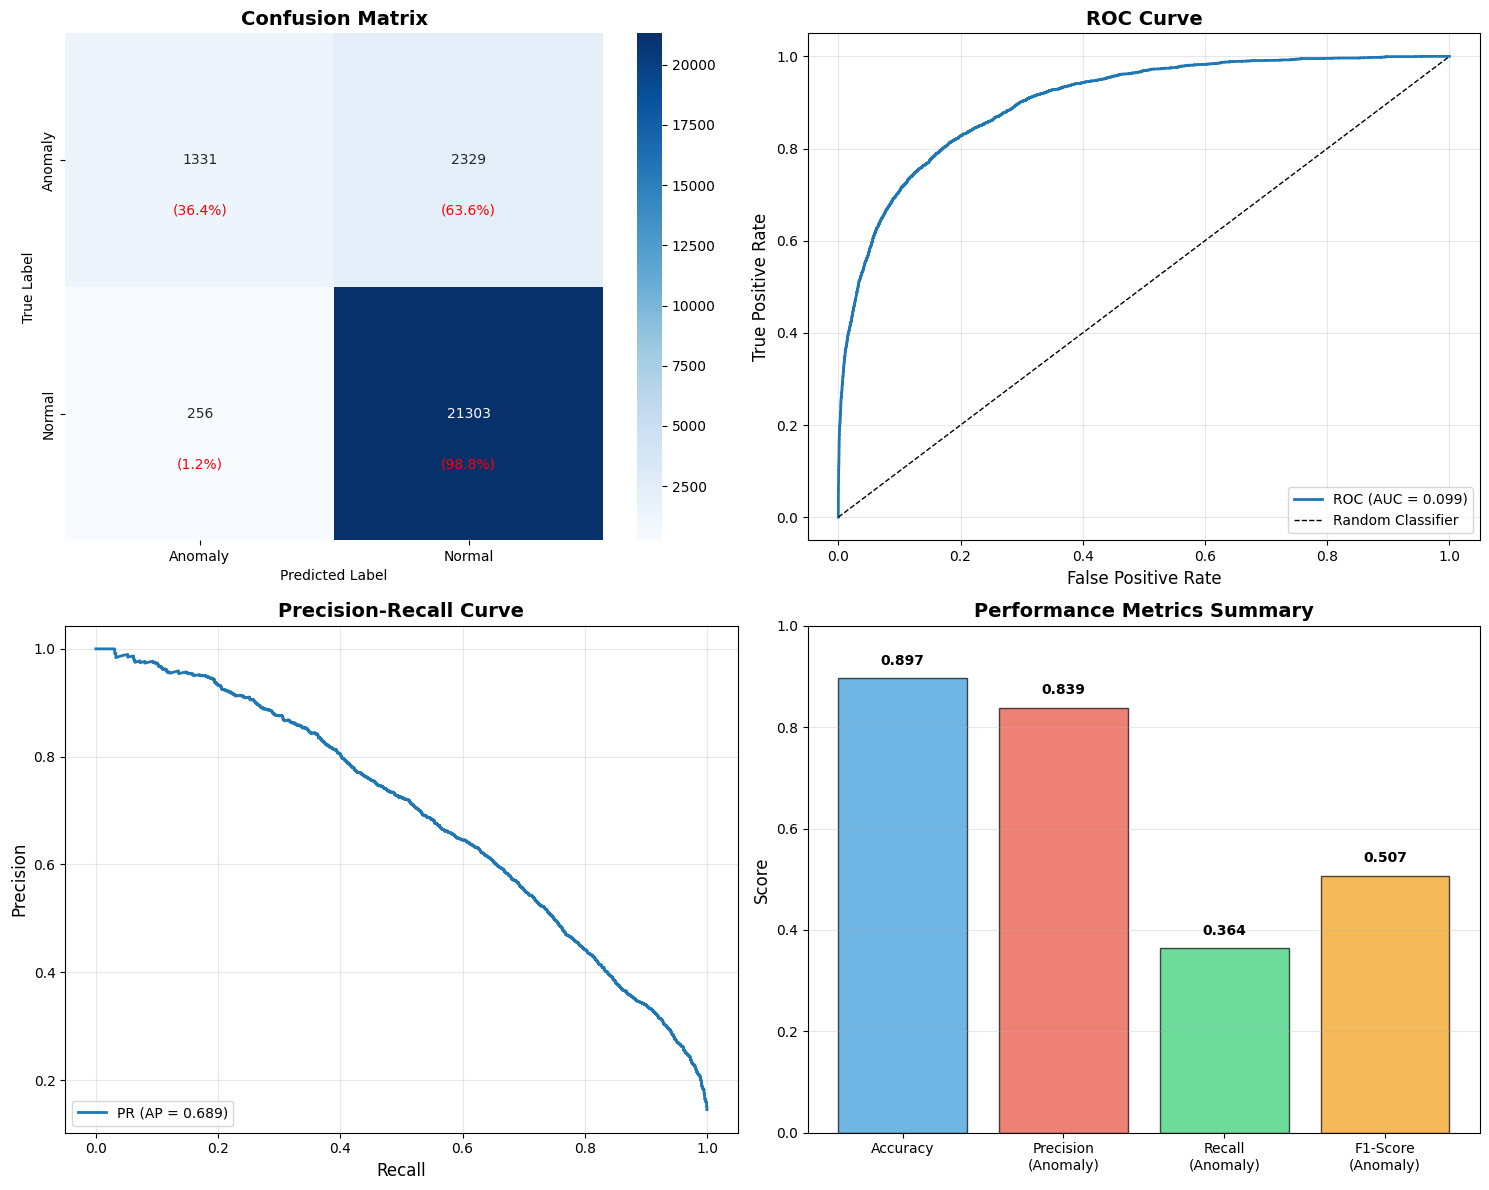

In [17]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Anomaly', 'Normal'], 
            yticklabels=['Anomaly', 'Normal'])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        axes[0, 0].text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                       ha='center', va='center', fontsize=10, color='red')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test == -1, y_pred_proba[:, 0])
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test == -1, y_pred_proba[:, 0])
axes[1, 0].plot(recall_curve, precision_curve, linewidth=2, 
               label=f'PR (AP = {avg_precision:.3f})')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='lower left')
axes[1, 0].grid(True, alpha=0.3)

# 4. Metrics Comparison Bar Chart
metrics_names = ['Accuracy', 'Precision\n(Anomaly)', 'Recall\n(Anomaly)', 'F1-Score\n(Anomaly)']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Performance Metrics Summary', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# Analysis of Misclassified Samples
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60)

# Get misclassified indices
misclassified_idx = y_test != y_pred
misclassified_samples = X_test[misclassified_idx]
misclassified_true = y_test[misclassified_idx]
misclassified_pred = y_pred[misclassified_idx]

# False Positives: Predicted anomaly but actually normal
false_positives = (y_pred == -1) & (y_test == 1)
fp_count = false_positives.sum()

# False Negatives: Predicted normal but actually anomaly
false_negatives = (y_pred == 1) & (y_test == -1)
fn_count = false_negatives.sum()

print(f"\nMisclassification Summary:")
print(f"  Total Misclassified:  {misclassified_idx.sum():,} / {len(y_test):,} ({misclassified_idx.sum()/len(y_test)*100:.2f}%)")
print(f"  False Positives (FP): {fp_count:,} (Normal predicted as Anomaly)")
print(f"  False Negatives (FN): {fn_count:,} (Anomaly predicted as Normal)")
print(f"\nCritical Issue: {fn_count:,} anomalies were MISSED by the model!")

# Show statistics of misclassified samples
if fn_count > 0:
    print(f"\nFalse Negatives - Average Feature Values:")
    fn_features = X_test[false_negatives]
    for i, col in enumerate(x.columns):
        print(f"  {col:15s}: {fn_features.iloc[:, i].mean():10.2f} (std: {fn_features.iloc[:, i].std():.2f})")


MISCLASSIFICATION ANALYSIS

Misclassification Summary:
  Total Misclassified:  2,585 / 25,219 (10.25%)
  False Positives (FP): 256 (Normal predicted as Anomaly)
  False Negatives (FN): 2,329 (Anomaly predicted as Normal)

Critical Issue: 2,329 anomalies were MISSED by the model!

False Negatives - Average Feature Values:
  avg_snr        :      42.52 (std: 2.04)
  min_snr        :      30.14 (std: 6.20)
  max_residual   :       9.85 (std: 5.65)
  x_x            :  459815.82 (std: 285.78)
  y_x            : 5634280.96 (std: 139.67)
  z_x            : 2946482.01 (std: 249.23)
  ns             :      18.72 (std: 1.51)
  sdx(m)         :       4.84 (std: 0.83)
  sdy(m)         :      15.97 (std: 3.57)
  sdz(m)         :       7.87 (std: 1.29)


In [14]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
        Feature  Importance
2  max_residual    0.148700
1       min_snr    0.124194
5           z_x    0.103349
3           x_x    0.101522
9        sdz(m)    0.101418
4           y_x    0.095733
7        sdx(m)    0.095450
0       avg_snr    0.088322
8        sdy(m)    0.083990
6            ns    0.057321


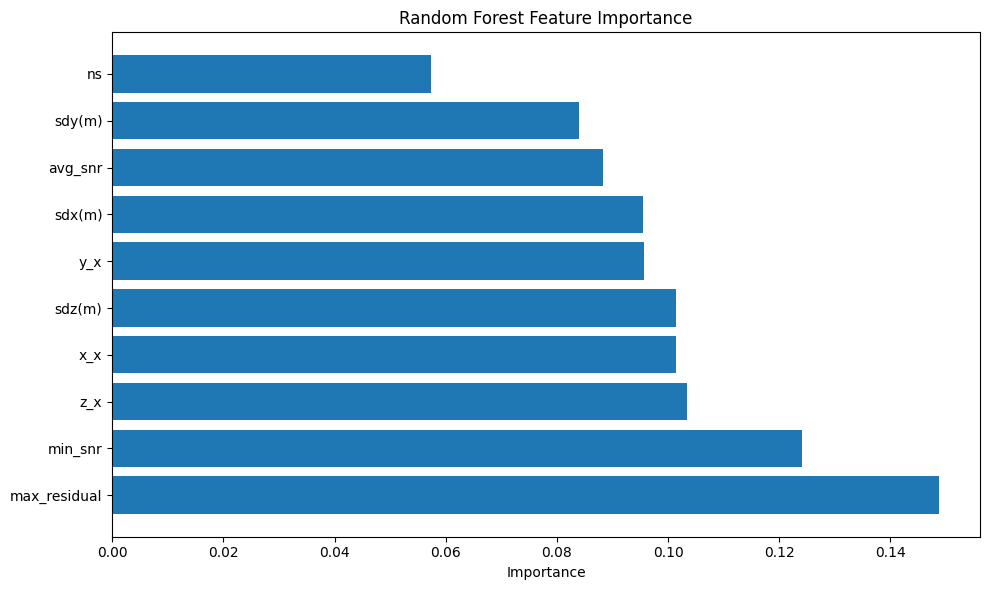

In [15]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()